# Hard Negative Mining

Анализ примеров, на которых BERT-модели ошибаются с высокой уверенностью.

Ноутбук выполняет:

- загрузку 6 BERT-моделей (RuBERT-tiny и RuBERT-tiny2, варианты raw/norm/p)
- получение предсказаний на внешнем тестовом датасете `test_preprocessed.csv`
- поиск false positives и false negatives с высокой уверенностью модели
- автоматическую категоризацию ошибок по типам
- анализ распределения ошибок по источнику данных и длине текста
- визуализацию результатов

Результаты помогают понять, какие типы сообщений труднее всего классифицировать,
и могут быть использованы для дообучения или аугментации данных.

## Импорты и настройка

In [1]:
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
)

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.transformer import bert_predict_batch, is_mostly_cyrillic
from src.config import PROCESSED_DIR, MODELS_DIR, INTERIM_DIR

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Загрузка тестовых данных

Загружается `test_preprocessed.csv` — внешний тестовый датасет, подготовленный в ноутбуке 01d. Не пересекается с обучающей выборкой.

In [2]:
df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv', index_col=0)
df_test = df_test.dropna(subset=['text_preprocessed']).reset_index(drop=True)

print(f'Размер тестовой выборки: {len(df_test)}')
print(f'Колонки: {list(df_test.columns)}')

_class_counts = df_test['label'].value_counts()
print(f'Ham (0): {_class_counts.get(0, 0)}')
print(f'Spam (1): {_class_counts.get(1, 0)}')

Размер тестовой выборки: 41369
Колонки: ['label', 'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length', 'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length', 'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count', 'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count', 'has_markdown', 'emoji_diversity', 'text_raw', 'text_normalized', 'text_preprocessed']
Ham (0): 22625
Spam (1): 18744


## Загрузка BERT-моделей

Загружаются 6 дообученных BERT-моделей:
- RuBERT-tiny: raw, norm, p
- RuBERT-tiny2: raw, norm, p

Для каждой модели указывается вариант текста, на котором она обучалась, и порог классификации (значения из ноутбука 05).

In [3]:
BERT_VARIANTS = [
    {'label': 'rubert_tiny2_raw', 'dir': 'finetuned_rubert_tiny2_raw', 'text_col': 'text_raw', 'threshold': 0.856187},
    {'label': 'rubert_tiny2_norm', 'dir': 'finetuned_rubert_tiny2_norm', 'text_col': 'text_normalized', 'threshold': 0.815507},
    {'label': 'rubert_tiny2_p', 'dir': 'finetuned_rubert_tiny2_p', 'text_col': 'text_preprocessed', 'threshold': 0.951362},
    {'label': 'rubert_tiny_raw', 'dir': 'finetuned_rubert_tiny_raw', 'text_col': 'text_raw', 'threshold': 0.814425},
    {'label': 'rubert_tiny_norm', 'dir': 'finetuned_rubert_tiny_norm', 'text_col': 'text_normalized', 'threshold': 0.802793},
    {'label': 'rubert_tiny_p', 'dir': 'finetuned_rubert_tiny_p', 'text_col': 'text_preprocessed', 'threshold': 0.939308},
]

bert_classifiers = {}
for variant in BERT_VARIANTS:
    model_path = str(MODELS_DIR / variant['dir'])
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_classifiers[variant['label']] = pipeline(
        'text-classification',
        model=model,
        tokenizer=tokenizer,
        device='cpu',
        truncation=True,
        max_length=256,
    )
    print(f'Загружена модель: {variant["label"]}')

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny2_raw


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny2_norm


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

...

Загружена модель: rubert_tiny_raw


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny_norm


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Загружена модель: rubert_tiny_p


## Получение предсказаний

Для каждой модели выполняется предсказание на соответствующем варианте текста. Сохраняются метки и вероятности класса spam.

In [4]:
test_labels = df_test['label'].values

bert_preds_all = {}
bert_proba_all = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    texts = df_test[variant['text_col']].astype(str).tolist()
    results = bert_predict_batch(
        texts,
        bert_classifiers[label],
        threshold=variant['threshold'],
        batch_size=16,
    )
    bert_preds_all[label] = np.array([r[0] for r in results])
    bert_proba_all[label] = np.array([r[1][1] for r in results])
    spam_count = bert_preds_all[label].sum()
    ham_count = (bert_preds_all[label] == 0).sum()
    print(f'{label}: spam={spam_count}, ham={ham_count}')

rubert_tiny2_raw: spam=16900, ham=24469
rubert_tiny2_norm: spam=16967, ham=24402
rubert_tiny2_p: spam=16987, ham=24382
rubert_tiny_raw: spam=17054, ham=24315
rubert_tiny_norm: spam=16936, ham=24433
rubert_tiny_p: spam=16887, ham=24482


## Hard Negative Mining

Для каждой модели находятся false positives (ham, ошибочно классифицированный как spam) и false negatives (spam, пропущенный моделью). Ошибки сортируются по уверенности модели — наиболее уверенные ошибки первыми.

In [5]:
hnm_results = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    preds = bert_preds_all[label]
    proba = bert_proba_all[label]

    fp_mask = (test_labels == 0) & (preds == 1)
    fn_mask = (test_labels == 1) & (preds == 0)

    fp_indices = np.where(fp_mask)[0]
    fn_indices = np.where(fn_mask)[0]

    fp_confidence = proba[fp_indices]
    fn_confidence = 1 - proba[fn_indices]

    fp_sorted = fp_indices[np.argsort(-fp_confidence)]
    fn_sorted = fn_indices[np.argsort(-fn_confidence)]

    hnm_results[label] = {
        'fp_indices': fp_sorted,
        'fn_indices': fn_sorted,
        'fp_count': int(fp_mask.sum()),
        'fn_count': int(fn_mask.sum()),
        'total_errors': int(fp_mask.sum() + fn_mask.sum()),
    }

    print(f'{label}: FP={hnm_results[label]["fp_count"]}, FN={hnm_results[label]["fn_count"]}, всего ошибок={hnm_results[label]["total_errors"]}')

rubert_tiny2_raw: FP=19, FN=1863, всего ошибок=1882
rubert_tiny2_norm: FP=27, FN=1804, всего ошибок=1831
rubert_tiny2_p: FP=20, FN=1777, всего ошибок=1797
rubert_tiny_raw: FP=20, FN=1710, всего ошибок=1730
rubert_tiny_norm: FP=49, FN=1857, всего ошибок=1906
rubert_tiny_p: FP=17, FN=1874, всего ошибок=1891


## Топ-20 наиболее уверенных false positives

False positives — обычные сообщения, ошибочно классифицированные как спам. Выводятся топ-20 по убыванию уверенности модели для каждой модели.

In [6]:
raw_texts = df_test['text_raw'].astype(str).tolist()

for variant in BERT_VARIANTS:
    label = variant['label']
    proba = bert_proba_all[label]
    fp_indices = hnm_results[label]['fp_indices']

    print(f'\n{label} — False Positives: {hnm_results[label]["fp_count"]}')
    print(f'Топ-20 FP (ham -> spam):\n')
    for idx in fp_indices[:20]:
        text = raw_texts[idx][:150]
        print(f'  [prob={proba[idx]:.4f}] {text}\n')
    print()


rubert_tiny2_raw — False Positives: 19
Топ-20 FP (ham -> spam):

  [prob=0.9761] Есть, пиши в лс

  [prob=0.9653] Работа в Москве! В столовую на раздачу и кассу требуются сотрудники. С 10.00 до 19.00. 2500 смена, питание бесплатно. м. Озёрная.

  [prob=0.9581] https://t.me/fsgn_active

  [prob=0.9561] https://t.me/jobrudn/2600

  [prob=0.9546] Нищебродским деньгам радоваться 🤦‍♀️

  [prob=0.9477] единороги делают меня счастливым каждый день. ЕДИНОРОГИ, ВПЕРЕД!!!!

  [prob=0.9431] Беседа мехмата в ТГ: https://t.me/+wrA-Fcx_PYA0YTYy

  [prob=0.9411] мечта+труд=успех👀

  [prob=0.9315] ТВОЮ МАТЬ, У МЕНЯ ДАЖЕ ПИСЬМО НЕ ОТПРАВЛЯЕТСЯ ИЗ-ЗА СБОЕВ 
ПИШЕТ, ЧТО В ОЧЕРЕДИ

  [prob=0.9151] https://band.link/Zqyka

  [prob=0.9032] пов: пишешь пробник

  [prob=0.9024] https://t.me/fcrudn

  [prob=0.9018] 汉语，只汉语✅

  [prob=0.8977] Здравствуйте!распространяется ли скидка 20% на категорию <<дети-инвалиды>>?

  [prob=0.8907] Хочу, хочу, 😅

  [prob=0.8812] Здравствуйте,в течении скольких дней после оплаты

## Топ-20 наиболее уверенных false negatives

False negatives — спам-сообщения, пропущенные моделью. Выводятся топ-20 по убыванию уверенности модели в ошибке.

In [7]:
for variant in BERT_VARIANTS:
    label = variant['label']
    proba = bert_proba_all[label]
    fn_indices = hnm_results[label]['fn_indices']

    print(f'\n{label} — False Negatives: {hnm_results[label]["fn_count"]}')
    print(f'Топ-20 FN (spam -> ham):\n')
    for idx in fn_indices[:20]:
        text = raw_texts[idx][:150]
        print(f'  [prob={proba[idx]:.4f}] {text}\n')
    print()


rubert_tiny2_raw — False Negatives: 1863
Топ-20 FN (spam -> ham):

  [prob=0.0057] Почему так долго? Вы про «οριστική άδεια διαμονής», пятилетний? Мне дали за 6 месяцев. Вас на собеседование приглашали?

  [prob=0.0059] Κυριακή - воскресенье

  [prob=0.0059] Σάββατο суббота

  [prob=0.0065] Но государство их поддерживает если им дали возможность попасть в раду

  [prob=0.0065] Добрый день! Подскажите пожалуйста, есть ли возможность попасть в государственный (!)детский сад с российским гражданством в Ереване? Если да, что для

  [prob=0.0074] 11.75 البته

  [prob=0.0076] Computer البته

  [prob=0.0076] π899

  [prob=0.0078] 92 دورنگ

  [prob=0.0079] Чтоб увеличить длину, надо с утра принимать обычный, советский…читать продолжение в источнике

  [prob=0.0080] 12.5 شدم

  [prob=0.0080] 13k دهنت

  [prob=0.0081] не знаешь как с кайфом провести выходные ?) У нас есть всё что утешит твои прихоти 😉🔞💊🌲🍀

  [prob=0.0081] 📢 Внимание! В Интернете появился секретный отчет о последней волне мобили

## Категоризация ошибок

Каждая ошибка автоматически классифицируется по типу:

- **non_russian** — текст не содержит кириллицы или доля кириллицы ниже 30%
- **short_with_contact** — короткое сообщение (до 50 символов) с фразами «пиши в лс», «напишите в личку» и подобными
- **legitimate_job** — содержит слова о работе, но без спам-маркеров
- **telegram_link** — содержит t.me ссылки или @username, но без спам-маркеров
- **contains_link** — содержит URL, но без спам-маркеров
- **near_boundary** — confidence модели в диапазоне 0.4–0.6
- **other** — не попадает в вышеописанные категории

In [8]:
SPAM_MARKERS = [
    'казино', 'выигрыш', 'выиграл', 'депозит', 'криптовалют', 'usdt',
    'bitcoin', 'ставка', 'букмекер', 'бонус', 'заработок', 'доход',
    'пирамид', 'инвест', 'forex', 'трейдинг', 'обнал', 'отмыв',
]

JOB_MARKERS = [
    'вакансия', 'требуется', 'работа', 'смена', 'зарплата',
    'оплата', 'нанят', 'сотрудник', 'раздача', 'касса',
]

CONTACT_PATTERNS = [
    'пиши в лс', 'пишите в лс', 'пиши в личку', 'пишите в личку',
    'напиши в лс', 'напишите в лс', 'напиши в личку', 'напишите в личку',
    'в личку', 'в лс', 'в личные сообщения',
]


def categorize_error(text, proba_spam):
    """Определяет категорию ошибки по тексту и уверенности модели."""
    text_lower = text.lower()
    has_spam_marker = any(m in text_lower for m in SPAM_MARKERS)

    if not is_mostly_cyrillic(text):
        return 'non_russian'

    if len(text) <= 50 and any(p in text_lower for p in CONTACT_PATTERNS):
        return 'short_with_contact'

    if any(m in text_lower for m in JOB_MARKERS) and not has_spam_marker:
        return 'legitimate_job'

    if ('t.me' in text_lower or '@' in text) and not has_spam_marker:
        return 'telegram_link'

    if ('http' in text_lower or 'www.' in text_lower) and not has_spam_marker:
        return 'contains_link'

    if 0.4 <= proba_spam <= 0.6:
        return 'near_boundary'

    return 'other'

In [9]:
error_categories = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    proba = bert_proba_all[label]
    text_col = variant['text_col']
    texts = df_test[text_col].astype(str).tolist()

    fp_cats = []
    for idx in hnm_results[label]['fp_indices']:
        fp_cats.append(categorize_error(texts[idx], proba[idx]))

    fn_cats = []
    for idx in hnm_results[label]['fn_indices']:
        fn_cats.append(categorize_error(texts[idx], proba[idx]))

    error_categories[label] = {
        'fp_categories': fp_cats,
        'fn_categories': fn_cats,
    }

    print(f'{label}: FP категоризовано={len(fp_cats)}, FN категоризовано={len(fn_cats)}')

rubert_tiny2_raw: FP категоризовано=19, FN категоризовано=1863
rubert_tiny2_norm: FP категоризовано=27, FN категоризовано=1804
rubert_tiny2_p: FP категоризовано=20, FN категоризовано=1777
rubert_tiny_raw: FP категоризовано=20, FN категоризовано=1710
rubert_tiny_norm: FP категоризовано=49, FN категоризовано=1857
rubert_tiny_p: FP категоризовано=17, FN категоризовано=1874


In [10]:
from collections import Counter

CATEGORY_ORDER = [
    'non_russian', 'short_with_contact', 'legitimate_job',
    'telegram_link', 'contains_link', 'near_boundary', 'other',
]

category_summary = []

for variant in BERT_VARIANTS:
    label = variant['label']
    fp_counts = Counter(error_categories[label]['fp_categories'])
    fn_counts = Counter(error_categories[label]['fn_categories'])

    for cat in CATEGORY_ORDER:
        category_summary.append({
            'model': label,
            'error_type': 'FP',
            'category': cat,
            'count': fp_counts.get(cat, 0),
        })
        category_summary.append({
            'model': label,
            'error_type': 'FN',
            'category': cat,
            'count': fn_counts.get(cat, 0),
        })

cat_df = pd.DataFrame(category_summary)

for error_type in ['FP', 'FN']:
    print(f'\n{error_type} — распределение по категориям:\n')
    pivot = cat_df[cat_df['error_type'] == error_type].pivot_table(
        index='model', columns='category', values='count', fill_value=0,
    )
    pivot = pivot.reindex(columns=CATEGORY_ORDER, fill_value=0)
    print(pivot)
    print()


FP — распределение по категориям:

category           non_russian  short_with_contact  legitimate_job  \
model                                                                
rubert_tiny2_norm          9.0                 1.0             2.0   
rubert_tiny2_p            10.0                 1.0             2.0   
rubert_tiny2_raw           6.0                 1.0             2.0   
rubert_tiny_norm          15.0                 4.0             4.0   
rubert_tiny_p              7.0                 3.0             1.0   
rubert_tiny_raw            5.0                 4.0             1.0   

category           telegram_link  contains_link  near_boundary  other  
model                                                                  
rubert_tiny2_norm            2.0            0.0            0.0   13.0  
rubert_tiny2_p               0.0            0.0            0.0    7.0  
rubert_tiny2_raw             1.0            0.0            0.0    9.0  
rubert_tiny_norm             4.0           

## Анализ по источнику данных

Проверяется наличие колонки `_source` в тестовых данных. Если колонка доступна, выводится доля ошибок по источникам для каждой модели.

In [11]:
if '_source' in df_test.columns:
    source_analysis = []

    for variant in BERT_VARIANTS:
        label = variant['label']
        fp_indices = hnm_results[label]['fp_indices']
        fn_indices = hnm_results[label]['fn_indices']
        all_error_indices = list(set(fp_indices) | set(fn_indices))

        error_sources = df_test.iloc[all_error_indices]['_source'].value_counts()
        total_sources = df_test['_source'].value_counts()

        for source in total_sources.index:
            error_count = error_sources.get(source, 0)
            total_count = total_sources[source]
            source_analysis.append({
                'model': label,
                'source': source,
                'error_count': error_count,
                'total_count': total_count,
                'error_rate': error_count / total_count if total_count > 0 else 0,
            })

    source_df = pd.DataFrame(source_analysis)
    print('Доля ошибок по источникам данных:')
    print(source_df.to_string(index=False))
else:
    print('Колонка _source отсутствует в тестовых данных. Анализ по источнику пропускается.')

Колонка _source отсутствует в тестовых данных. Анализ по источнику пропускается.


## Анализ по длине текста

Тексты разбиваются на корзины по длине: <20, 20–50, 50–100, 100–200, 200–500, 500+. Для каждой модели выводится количество FP и FN по корзинам.

In [12]:
LENGTH_BINS = [0, 20, 50, 100, 200, 500, float('inf')]
LENGTH_LABELS = ['<20', '20-50', '50-100', '100-200', '200-500', '500+']

df_test['text_length'] = df_test['text_raw'].astype(str).str.len()
df_test['length_bin'] = pd.cut(
    df_test['text_length'],
    bins=LENGTH_BINS,
    labels=LENGTH_LABELS,
    right=False,
)

length_analysis = []

for variant in BERT_VARIANTS:
    label = variant['label']
    fp_indices = hnm_results[label]['fp_indices']
    fn_indices = hnm_results[label]['fn_indices']

    fp_bins = df_test.iloc[fp_indices]['length_bin'].value_counts().reindex(LENGTH_LABELS, fill_value=0)
    fn_bins = df_test.iloc[fn_indices]['length_bin'].value_counts().reindex(LENGTH_LABELS, fill_value=0)
    total_bins = df_test['length_bin'].value_counts().reindex(LENGTH_LABELS, fill_value=0)

    for bin_label in LENGTH_LABELS:
        length_analysis.append({
            'model': label,
            'length_bin': bin_label,
            'fp_count': fp_bins[bin_label],
            'fn_count': fn_bins[bin_label],
            'total_count': total_bins[bin_label],
        })

length_df = pd.DataFrame(length_analysis)
print('Распределение ошибок по длине текста:')
print(length_df.to_string(index=False))

Распределение ошибок по длине текста:
            model length_bin  fp_count  fn_count  total_count
 rubert_tiny2_raw        <20         6      1076         4202
 rubert_tiny2_raw      20-50         5       342         6726
 rubert_tiny2_raw     50-100         5       204         9204
 rubert_tiny2_raw    100-200         2       140         9929
 rubert_tiny2_raw    200-500         0        89         8572
 rubert_tiny2_raw       500+         1        12         2736
rubert_tiny2_norm        <20         5      1031         4202
rubert_tiny2_norm      20-50         6       398         6726
rubert_tiny2_norm     50-100         9       125         9204
rubert_tiny2_norm    100-200         5        93         9929
rubert_tiny2_norm    200-500         1        86         8572
rubert_tiny2_norm       500+         1        71         2736
   rubert_tiny2_p        <20         3       666         4202
   rubert_tiny2_p      20-50         5       421         6726
   rubert_tiny2_p     50-100    

## Визуализация

Три графика:
- Heatmap: модели × категории ошибок (количество FP и FN)
- Bar chart: ошибки по корзинам длины текста
- Гистограмма: распределение confidence для FP и FN

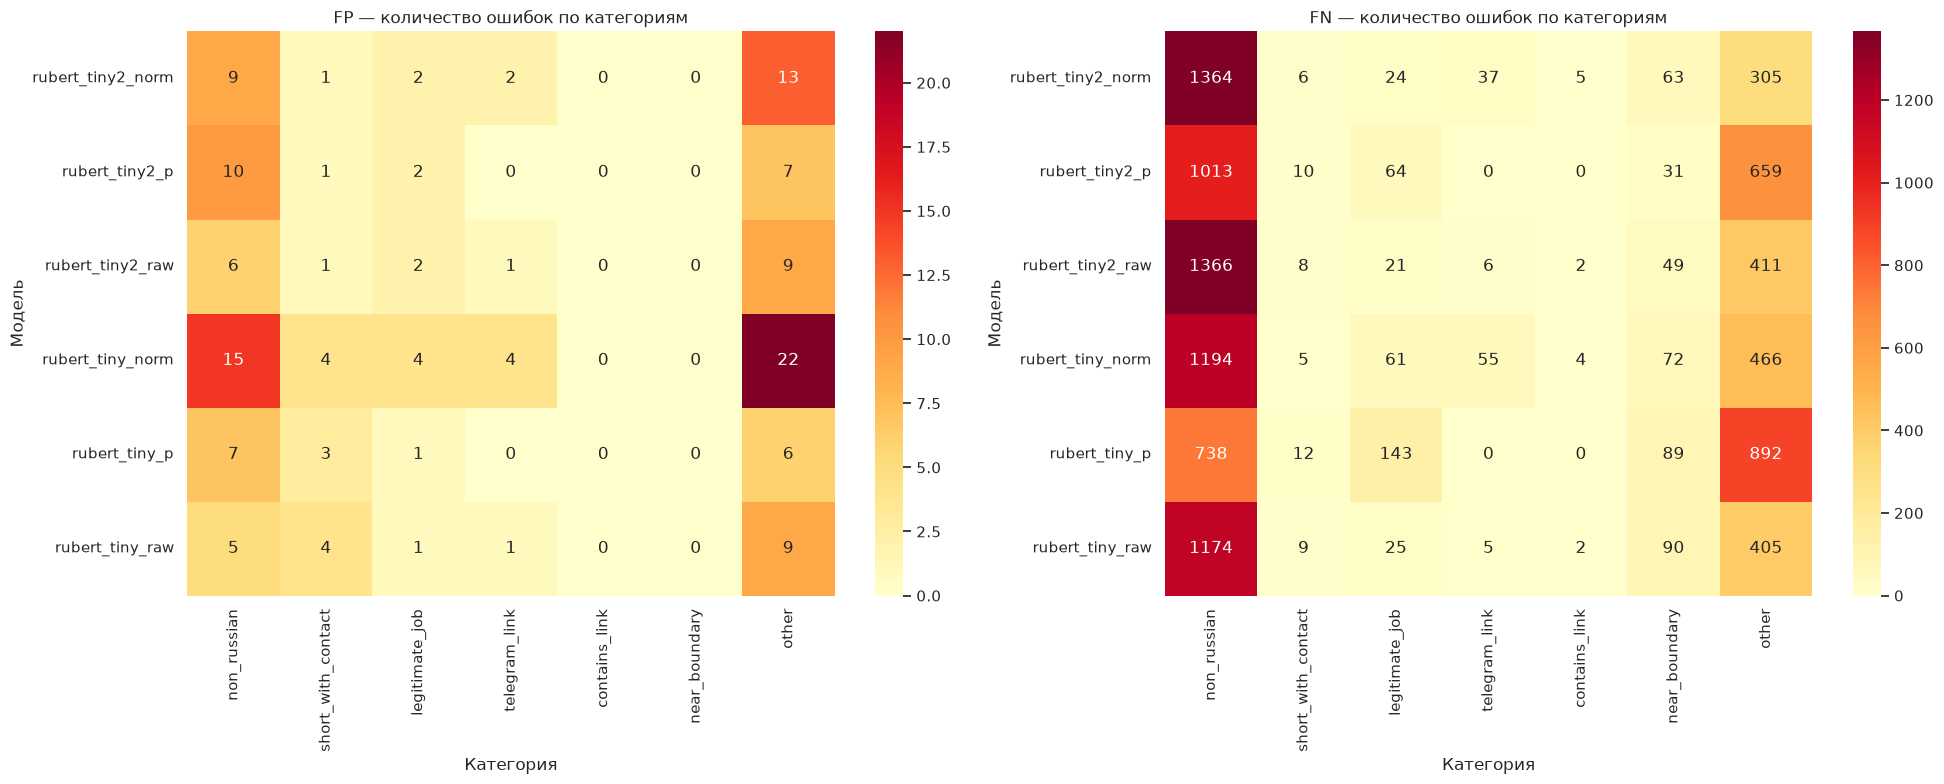

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax_idx, error_type in enumerate(['FP', 'FN']):
    pivot = cat_df[cat_df['error_type'] == error_type].pivot_table(
        index='model', columns='category', values='count', fill_value=0,
    )
    pivot = pivot.reindex(columns=CATEGORY_ORDER, fill_value=0).astype(int)
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[ax_idx])
    axes[ax_idx].set_title(f'{error_type} — количество ошибок по категориям')
    axes[ax_idx].set_xlabel('Категория')
    axes[ax_idx].set_ylabel('Модель')

plt.tight_layout()
plt.show()

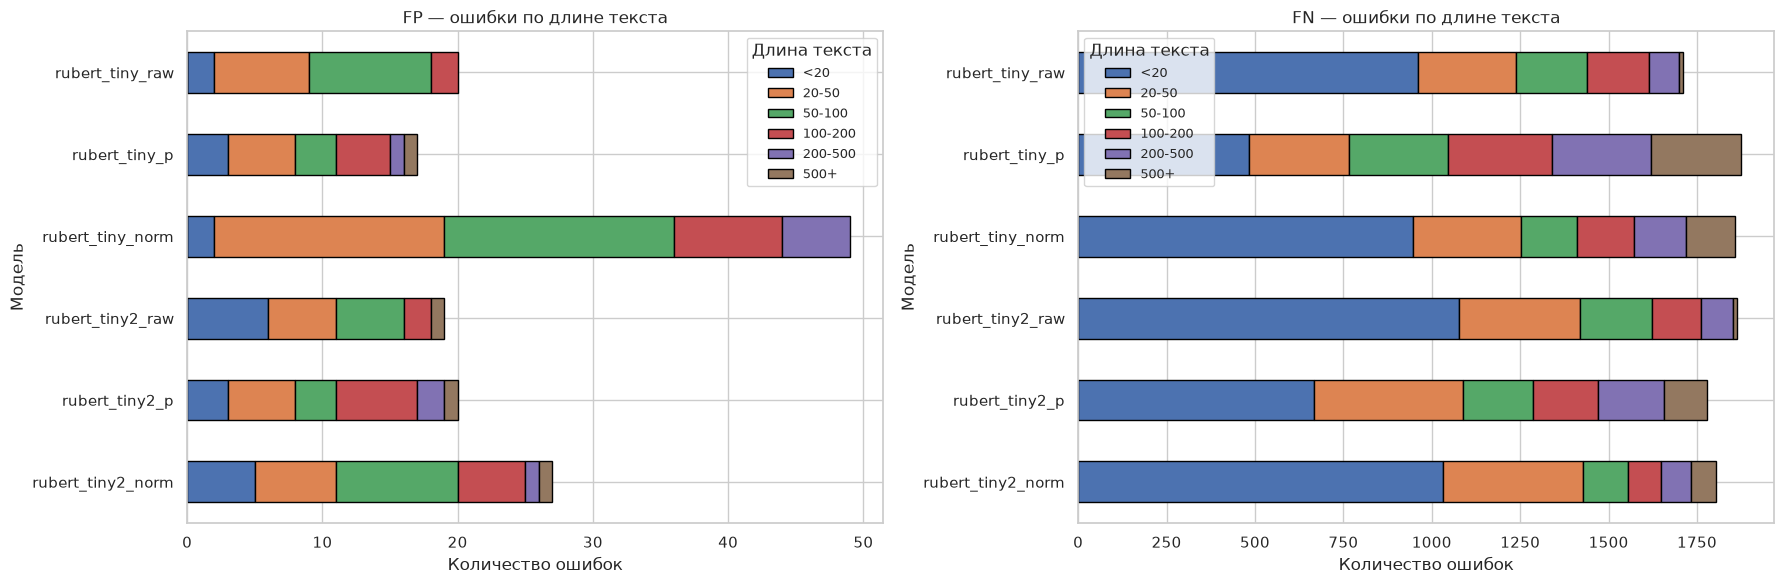

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax_idx, error_type in enumerate(['FP', 'FN']):
    col = 'fp_count' if error_type == 'FP' else 'fn_count'
    pivot = length_df.pivot_table(index='model', columns='length_bin', values=col, fill_value=0)
    pivot = pivot.reindex(columns=LENGTH_LABELS, fill_value=0)
    pivot.plot(kind='barh', stacked=True, ax=axes[ax_idx], edgecolor='black')
    axes[ax_idx].set_title(f'{error_type} — ошибки по длине текста')
    axes[ax_idx].set_xlabel('Количество ошибок')
    axes[ax_idx].set_ylabel('Модель')
    axes[ax_idx].legend(title='Длина текста', fontsize=9)

plt.tight_layout()
plt.show()

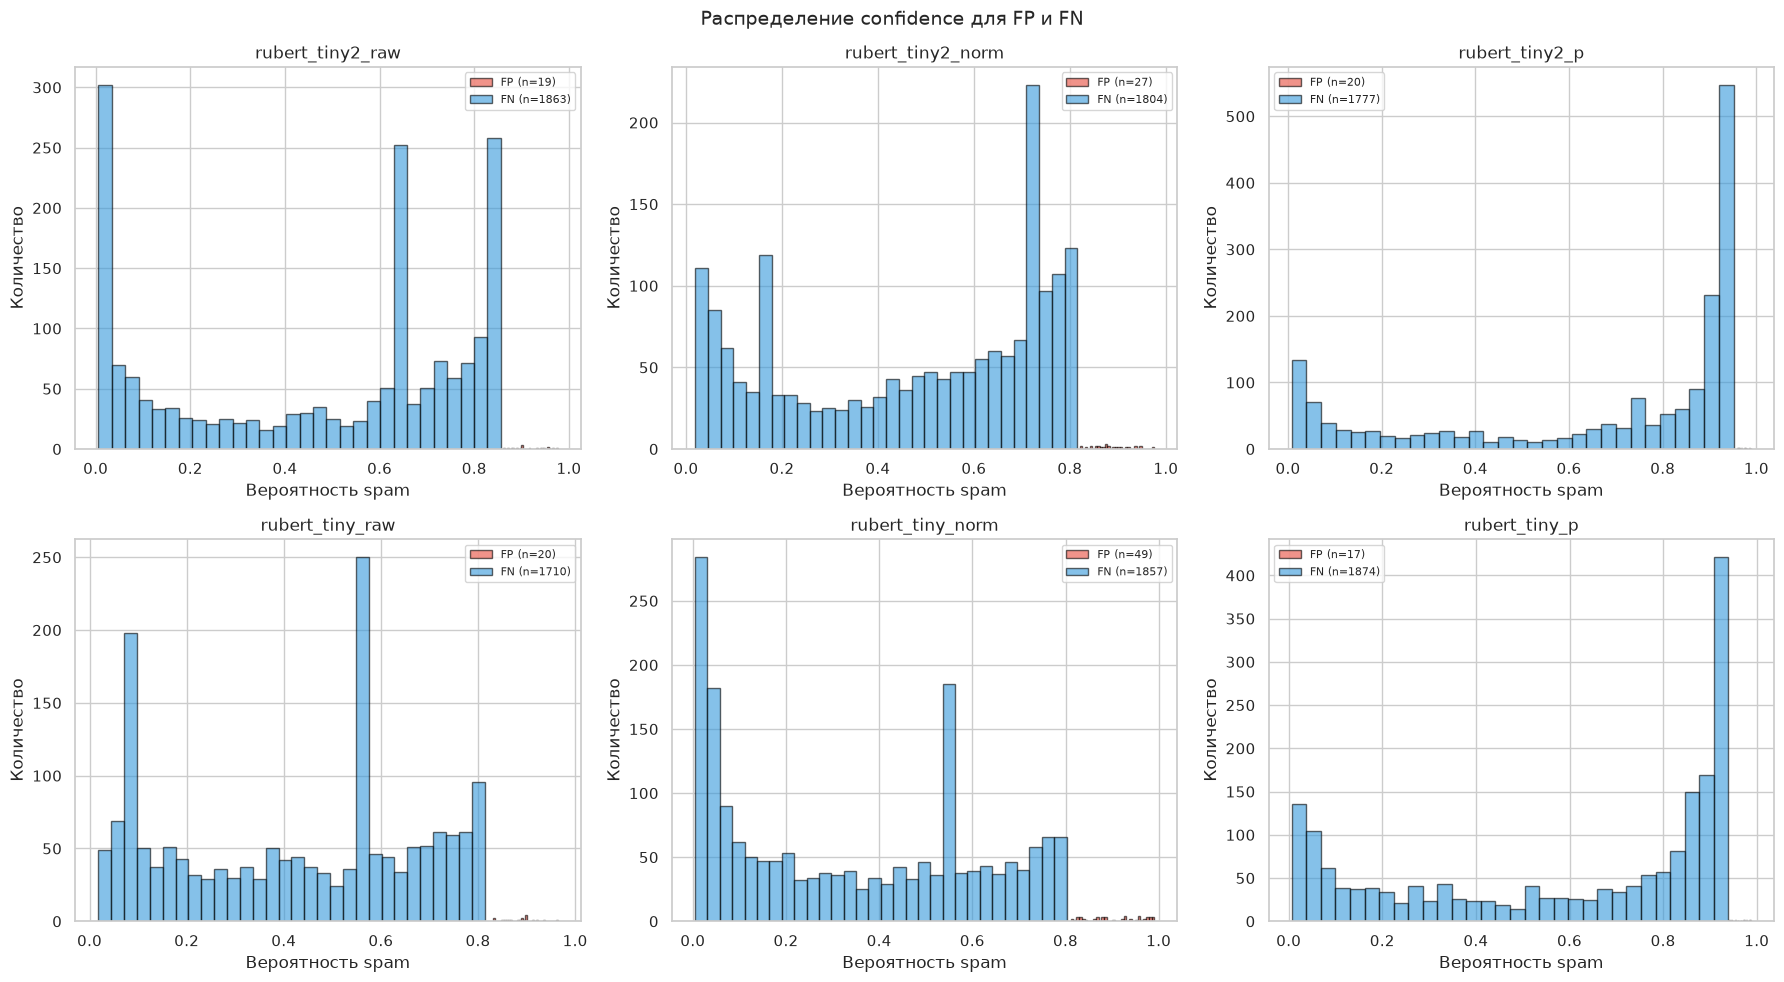

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, variant in enumerate(BERT_VARIANTS):
    label = variant['label']
    proba = bert_proba_all[label]
    fp_indices = hnm_results[label]['fp_indices']
    fn_indices = hnm_results[label]['fn_indices']

    fp_proba = proba[fp_indices]
    fn_proba = proba[fn_indices]

    ax = axes_flat[idx]
    if len(fp_proba) > 0:
        ax.hist(fp_proba, bins=30, alpha=0.6, color='#e74c3c', label=f'FP (n={len(fp_proba)})', edgecolor='black')
    if len(fn_proba) > 0:
        ax.hist(fn_proba, bins=30, alpha=0.6, color='#3498db', label=f'FN (n={len(fn_proba)})', edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('Вероятность spam')
    ax.set_ylabel('Количество')
    ax.legend(fontsize=8)

plt.suptitle('Распределение confidence для FP и FN', fontsize=14)
plt.tight_layout()
plt.show()

## Сохранение результатов

Индексы hard negatives и их категории сохраняются в `data/interim/hard_negatives.pkl`. Сводная таблица метрик сохраняется в `data/interim/hnm_summary.csv`.

In [17]:
hnm_export = {}
for variant in BERT_VARIANTS:
    label = variant['label']
    hnm_export[label] = {
        'fp_indices': hnm_results[label]['fp_indices'].tolist(),
        'fn_indices': hnm_results[label]['fn_indices'].tolist(),
        'fp_categories': error_categories[label]['fp_categories'],
        'fn_categories': error_categories[label]['fn_categories'],
        'fp_count': hnm_results[label]['fp_count'],
        'fn_count': hnm_results[label]['fn_count'],
        'total_errors': hnm_results[label]['total_errors'],
    }

with open(INTERIM_DIR / 'hard_negatives.pkl', 'wb') as f:
    pickle.dump(hnm_export, f)

summary_rows = []
for variant in BERT_VARIANTS:
    label = variant['label']
    summary_rows.append({
        'model': label,
        'fp_count': hnm_results[label]['fp_count'],
        'fn_count': hnm_results[label]['fn_count'],
        'total_errors': hnm_results[label]['total_errors'],
        'threshold': variant['threshold'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(INTERIM_DIR / 'hnm_summary.csv', index=False)

print(f'Сохранено: {INTERIM_DIR / "hard_negatives.pkl"}')
print(f'Сохранено: {INTERIM_DIR / "hnm_summary.csv"}')
print()
print(summary_df.to_string(index=False))

Сохранено: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/hard_negatives.pkl
Сохранено: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/hnm_summary.csv

            model  fp_count  fn_count  total_errors  threshold
 rubert_tiny2_raw        19      1863          1882   0.856187
rubert_tiny2_norm        27      1804          1831   0.815507
   rubert_tiny2_p        20      1777          1797   0.951362
  rubert_tiny_raw        20      1710          1730   0.814425
 rubert_tiny_norm        49      1857          1906   0.802793
    rubert_tiny_p        17      1874          1891   0.939308


## Выводы

Сводка по результатам анализа: наиболее частые категории ошибок, модели с наибольшим количеством ошибок, паттерны по длине текста.

In [18]:
print('Сводка по моделям:')
print()
for variant in BERT_VARIANTS:
    label = variant['label']
    r = hnm_results[label]
    fp_cats = Counter(error_categories[label]['fp_categories'])
    fn_cats = Counter(error_categories[label]['fn_categories'])
    top_fp_cat = fp_cats.most_common(1)[0] if fp_cats else ('нет', 0)
    top_fn_cat = fn_cats.most_common(1)[0] if fn_cats else ('нет', 0)

    print(f'{label}:')
    print(f'  Всего ошибок: {r["total_errors"]} (FP={r["fp_count"]}, FN={r["fn_count"]})')
    print(f'  Топ FP категория: {top_fp_cat[0]} ({top_fp_cat[1]})')
    print(f'  Топ FN категория: {top_fn_cat[0]} ({top_fn_cat[1]})')
    print()

print('Общие наблюдения:')
all_fp_cats = Counter()
all_fn_cats = Counter()
for label in error_categories:
    all_fp_cats.update(error_categories[label]['fp_categories'])
    all_fn_cats.update(error_categories[label]['fn_categories'])

print(f'  Наиболее частая FP категория: {all_fp_cats.most_common(3)}')
print(f'  Наиболее частая FN категория: {all_fn_cats.most_common(3)}')

Сводка по моделям:

rubert_tiny2_raw:
  Всего ошибок: 1882 (FP=19, FN=1863)
  Топ FP категория: other (9)
  Топ FN категория: non_russian (1366)

rubert_tiny2_norm:
  Всего ошибок: 1831 (FP=27, FN=1804)
  Топ FP категория: other (13)
  Топ FN категория: non_russian (1364)

rubert_tiny2_p:
  Всего ошибок: 1797 (FP=20, FN=1777)
  Топ FP категория: non_russian (10)
  Топ FN категория: non_russian (1013)

rubert_tiny_raw:
  Всего ошибок: 1730 (FP=20, FN=1710)
  Топ FP категория: other (9)
  Топ FN категория: non_russian (1174)

rubert_tiny_norm:
  Всего ошибок: 1906 (FP=49, FN=1857)
  Топ FP категория: other (22)
  Топ FN категория: non_russian (1194)

rubert_tiny_p:
  Всего ошибок: 1891 (FP=17, FN=1874)
  Топ FP категория: non_russian (7)
  Топ FN категория: other (892)

Общие наблюдения:
  Наиболее частая FP категория: [('other', 66), ('non_russian', 52), ('short_with_contact', 14)]
  Наиболее частая FN категория: [('non_russian', 6849), ('other', 3138), ('near_boundary', 394)]
